# avOTU Quality Robustness

CheckV quality sensitivity analyses for prevalence, lifestyle, and community concordance.

## Notebook Setup

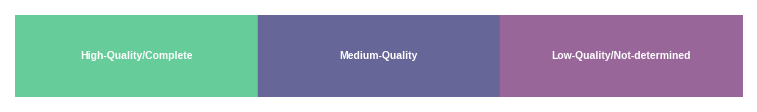

In [10]:
# Load core libraries and define notebook settings
# Load core libraries
from pathlib import Path

# Load data libraries
import numpy as np
import pandas as pd

# Load plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Load stats libraries
from scipy.spatial.distance import pdist, squareform
from scipy.stats import mannwhitneyu, rankdata, wilcoxon

# Plotting preferences
sns.set_style(
    "ticks",
    {
        "axes.grid": True,
        "grid.color": "#BFBFBF",
        "grid.linestyle": "-",
        "grid.linewidth": 0.35,
        "axes.facecolor": "white",
        "figure.facecolor": "white",
    },
)
sns.set_palette("colorblind")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
    "savefig.bbox": "tight",
    "axes.linewidth": 0.7,
    "axes.edgecolor": "#222222",
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.major.size": 4.5,
    "ytick.major.size": 4.5,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "grid.linewidth": 0.35,
    "grid.alpha": 0.8,
    "patch.linewidth": 0.7,
    "lines.linewidth": 1.0,
    "lines.markersize": 4,
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans"],
    "text.usetex": False,
    "font.size": 5,
    "axes.titlepad": 5,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "legend.frameon": True,
    "legend.fancybox": False,
    "legend.framealpha": 1.0,
    "legend.edgecolor": "#444444",
    "legend.facecolor": "white",
    "legend.fontsize": 5,
    "legend.title_fontsize": 6,
    "savefig.dpi": 300,
    "figure.dpi": 150,
    "svg.fonttype": "none",
})

# Set paths and shared variables
VIRAL_FRACTION_DIR = Path("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION")
FIGURES_TABLES_DIR = VIRAL_FRACTION_DIR / "FIGURES_AND_TABLES"
SUP_FIGS_TABLES_DIR = FIGURES_TABLES_DIR / "SUP_FIGS_TABLES"
SUP_FIGS_TABLES_DIR.mkdir(parents=True, exist_ok=True)
VIRAL_MAPPING_REFERENCES_DIR = VIRAL_FRACTION_DIR / "06_MAPPING" / "REFERENCES"
VOTU_METADATA_PATH = VIRAL_FRACTION_DIR / "vOTU_metadata.csv"

THRESHOLD_SELECTION_OUTPUT_DIR = (
    FIGURES_TABLES_DIR
    / "SUPPLEMENTARY"
    / "11_rank_abundance_threshold_selection"
)
FULL_THRESHOLD_MEMBERSHIP_PATH = (
    THRESHOLD_SELECTION_OUTPUT_DIR / "11_full_phyllosphere_threshold_membership.csv"
)
RPKM_PATH = (
    VIRAL_MAPPING_REFERENCES_DIR
    / "filtered_active_vOTUs_threshold_1p5_RPKM_normalised_tot.txt"
)

BACTERIAL_JACCARD_PATH = FIGURES_TABLES_DIR / "bacterial_jaccard_matrix.csv"
BACTERIAL_HELLINGER_PATH = FIGURES_TABLES_DIR / "bacterial_hellinger_matrix.csv"
VIRAL_JACCARD_PATH = FIGURES_TABLES_DIR / "viral_jaccard_matrix.csv"
VIRAL_HELLINGER_PATH = FIGURES_TABLES_DIR / "viral_hellinger_matrix.csv"

OUTPUT_DIR = (
    FIGURES_TABLES_DIR
    / "SUPPLEMENTARY"
    / "15_vOTU_quality_robustness"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define sample subsets
SAMPLES = [
    "vFL", "vOL", "vF23",
    "vN1", "vN2", "vN3",
    "vZ1", "vZ2", "vZ3",
    "vF1A", "vF2A", "vF3A",
    "vF1B", "vF2B", "vF3B",
    "vF1C", "vF2C", "vF3C",
    "vO1A", "vO2A", "vO3A",
    "vO1B", "vO2B", "vO3B",
    "vO1C", "vO2C", "vO3C",
    "vS1B", "vS2B", "vS3B",
    "vS1C", "vS2C", "vS3C",
    "vNWd", "vSWd", "vSEd",
]
SAMPLES_DK = SAMPLES[:33]

# Define analysis groups
DEFAULT_THRESHOLD_KEY = "1.5"
LIFESTYLE_ORDER = ["Temperate", "Virulent"]
QUALITY_SETS = [
    {
        "quality_set": "All vOTUs",
        "included_checkv_quality": "All CheckV calls",
        "allowed_checkv_quality": None,
    },
    {
        "quality_set": "Medium-quality or better",
        "included_checkv_quality": "Medium-quality, High-quality, Complete",
        "allowed_checkv_quality": {
            "Medium-quality",
            "High-quality",
            "Complete",
        },
    },
    {
        "quality_set": "High-quality or Complete",
        "included_checkv_quality": "High-quality, Complete",
        "allowed_checkv_quality": {"High-quality", "Complete"},
    },
]
QUALITY_SET_ORDER = [entry["quality_set"] for entry in QUALITY_SETS]
QUALITY_SET_COLORS = {
    "All vOTUs": "#3399CC",
    "Medium-quality or better": "#33CC99",
    "High-quality or Complete": "#FFCC00",
}

PREVALENCE_GROUP_ORDER = [
    "Not detected in Danish samples",
    "Low overlap/unique",
    "Common",
    "Core",
    "Ubiquitous",
]
PLOT_PREVALENCE_GROUPS = [
    "Ubiquitous",
    "Core",
    "Common",
    "Low overlap/unique",
]
# Define reusable functions
def plot_palette(palette):
    fig, ax = plt.subplots(figsize=(5, 0.7))
    for i, (category, color) in enumerate(palette.items()):
        ax.add_patch(
            plt.Rectangle(
                (i / len(palette), 0),
                1 / len(palette),
                1,
                color=color,
            )
        )
        ax.text(
            (i + 0.5) / len(palette),
            0.5,
            category.replace(" ", "\n"),
            ha="center",
            va="center",
            color="white",
            fontsize=5,
            fontweight="bold",
        )
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Define quality palette
palette_quality = {
    "High-Quality/Complete": "#66CC99",
    "Medium-Quality": "#666699",
    "Low-Quality/Not-determined": "#996699",
}

plot_palette(palette_quality)

QUALITY_CLASS_ORDER = list(palette_quality)
COMMUNITY_METRICS = [
    ("Jaccard", "Jaccard", "#222222"),
    ("Hellinger", "Hellinger", "#999999"),
]

N_MANTEL_PERMUTATIONS = 9_999
RANDOM_SEED = 20260730

def format_p_value(p_value):
    if pd.isna(p_value):
        return "NA"
    if p_value < 0.001:
        return "<0.001"
    return f"{p_value:.3f}"


def significance_label(p_value):
    if pd.isna(p_value):
        return "NA"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"


## Quality-Filtered avOTU Sets

In [11]:
# Load and validate quality-filtering inputs
required_paths = [
    FULL_THRESHOLD_MEMBERSHIP_PATH,
    RPKM_PATH,
    BACTERIAL_JACCARD_PATH,
    BACTERIAL_HELLINGER_PATH,
    VIRAL_JACCARD_PATH,
    VIRAL_HELLINGER_PATH,
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Required 15 inputs are missing: "
        f"{[str(path) for path in missing_paths]}"
    )

threshold_membership = pd.read_csv(
    FULL_THRESHOLD_MEMBERSHIP_PATH,
    dtype={"threshold_multiplier": str, "vOTU": str},
)
required_membership_columns = {
    "threshold_multiplier",
    "vOTU",
    "rank_abundance_call",
}
missing_membership_columns = sorted(
    required_membership_columns.difference(threshold_membership.columns)
)
if missing_membership_columns:
    raise ValueError(
        "11 membership table is missing columns: "
        f"{missing_membership_columns}"
    )

selected_votu_ids = set(
    threshold_membership.loc[
        threshold_membership["threshold_multiplier"].eq(DEFAULT_THRESHOLD_KEY)
        & threshold_membership["rank_abundance_call"].eq("retained"),
        "vOTU",
    ]
)
if not selected_votu_ids:
    raise ValueError("11 did not contain any retained 1.5x vOTUs.")

votu_metadata = pd.read_csv(VOTU_METADATA_PATH, low_memory=False)
votu_metadata["vOTU"] = votu_metadata["vOTU"].astype(str)
required_metadata_columns = {
    "vOTU",
    "checkv_quality",
    "resolved_lifestyle",
    "resolved_host_genus",
}
missing_metadata_columns = sorted(
    required_metadata_columns.difference(votu_metadata.columns)
)
if missing_metadata_columns:
    raise ValueError(
        "vOTU metadata are missing columns: "
        f"{missing_metadata_columns}"
    )

metadata_columns = [
    "vOTU",
    "checkv_quality",
    "resolved_lifestyle",
    "resolved_host_genus",
]

metadata_subset = votu_metadata.loc[
    votu_metadata["vOTU"].isin(selected_votu_ids),
    metadata_columns,
].copy()
if metadata_subset["vOTU"].duplicated().any():
    duplicate_ids = (
        metadata_subset.loc[
            metadata_subset["vOTU"].duplicated(),
            "vOTU",
        ]
        .head()
        .tolist()
    )
    raise ValueError(f"vOTU metadata contain duplicate IDs: {duplicate_ids}")

missing_metadata_ids = selected_votu_ids.difference(metadata_subset["vOTU"])
if missing_metadata_ids:
    raise ValueError(
        "vOTU metadata are missing 1.5x-selected IDs: "
        f"{sorted(missing_metadata_ids)[:5]}"
    )

rpkm = pd.read_csv(RPKM_PATH, low_memory=False)
rpkm["vOTU"] = rpkm["vOTU"].astype(str)
if rpkm["vOTU"].duplicated().any():
    duplicate_ids = rpkm.loc[rpkm["vOTU"].duplicated(), "vOTU"].head().tolist()
    raise ValueError(f"The 1.5x RPKM table contains duplicate IDs: {duplicate_ids}")

missing_samples = sorted(set(SAMPLES).difference(rpkm.columns))
if missing_samples:
    raise ValueError(
        "The 1.5x RPKM table is missing sample columns: "
        f"{missing_samples}"
    )

missing_rpkm_ids = selected_votu_ids.difference(rpkm["vOTU"])
if missing_rpkm_ids:
    raise ValueError(
        "The 1.5x RPKM table is missing selected vOTUs: "
        f"{sorted(missing_rpkm_ids)[:5]}"
    )

selected_votus = metadata_subset.merge(
    rpkm.loc[rpkm["vOTU"].isin(selected_votu_ids), ["vOTU"] + SAMPLES],
    on="vOTU",
    how="left",
    validate="one_to_one",
)
selected_votus[SAMPLES] = (
    selected_votus[SAMPLES]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

quality_sets = {}
quality_membership_rows = []
quality_summary_rows = []
all_selected_rpkm = selected_votus[SAMPLES].to_numpy().sum()

for definition in QUALITY_SETS:
    quality_set = definition["quality_set"]
    allowed_checkv_quality = definition["allowed_checkv_quality"]

    if allowed_checkv_quality is None:
        subset = selected_votus.copy()
    else:
        subset = selected_votus.loc[
            selected_votus["checkv_quality"].isin(allowed_checkv_quality)
        ].copy()

    if subset.empty:
        raise ValueError(f"{quality_set} contains no 1.5x-selected vOTUs.")

    quality_sets[quality_set] = subset
    quality_membership_rows.extend(
        {
            "quality_set": quality_set,
            "vOTU": row.vOTU,
            "checkv_quality": row.checkv_quality,
            "resolved_lifestyle": row.resolved_lifestyle,
        }
        for row in subset.itertuples(index=False)
    )

    total_votus = len(subset)
    temperate_count = int(subset["resolved_lifestyle"].eq("Temperate").sum())
    virulent_count = int(subset["resolved_lifestyle"].eq("Virulent").sum())
    lifestyle_called = subset["resolved_lifestyle"].isin(LIFESTYLE_ORDER)
    no_lifestyle_count = int((~lifestyle_called).sum())
    quality_summary_rows.append(
        {
            "quality_set": quality_set,
            "CheckV calls included": definition["included_checkv_quality"],
            "vOTUs": total_votus,
            "Temperate": temperate_count,
            "Temperate (%)": 100 * temperate_count / total_votus,
            "Virulent": virulent_count,
            "Virulent (%)": 100 * virulent_count / total_votus,
            "No lifestyle call": no_lifestyle_count,
            "No lifestyle call (%)": 100 * no_lifestyle_count / total_votus,
            "RPKM retained (%)": (
                100 * subset[SAMPLES].to_numpy().sum() / all_selected_rpkm
                if all_selected_rpkm > 0
                else np.nan
            ),
        }
    )

quality_set_summary = pd.DataFrame(quality_summary_rows)
quality_membership = pd.DataFrame(quality_membership_rows)

quality_set_summary.to_csv(
    OUTPUT_DIR / "15_quality_set_summary.csv",
    index=False,
)
quality_membership.to_csv(
    OUTPUT_DIR / "15_vOTU_quality_membership.csv",
    index=False,
)

quality_set_summary_display = quality_set_summary.copy()
for column in [
    "Temperate (%)",
    "Virulent (%)",
    "No lifestyle call (%)",
    "RPKM retained (%)",
]:
    quality_set_summary_display[column] = quality_set_summary_display[column].round(1)
quality_set_summary_display


,quality_set,CheckV calls included,vOTUs,Temperate,Temperate (%),Virulent,Virulent (%),No lifestyle call,No lifestyle call (%),RPKM retained (%)
0,All vOTUs,All CheckV calls,726,294,40.5,432,59.5,0,0.0,100.0
1,Medium-quality or better,"Medium-quality, High-quality, Complete",485,234,48.2,251,51.8,0,0.0,83.0
2,High-quality or Complete,"High-quality, Complete",317,155,48.9,162,51.1,0,0.0,66.7


## Prevalence Analysis

Retain the original prevalence-class definitions within each quality set.

In [12]:
# Define prevalence and quality classes
def prevalence_group(detected_samples):
    prevalence = detected_samples / len(SAMPLES_DK)
    if detected_samples == 0:
        return "Not detected in Danish samples"
    if prevalence < 0.20:
        return "Low overlap/unique"
    if prevalence < 0.50:
        return "Common"
    if prevalence < 1.00:
        return "Core"
    return "Ubiquitous"


def quality_class(checkv_quality):
    if checkv_quality in {"High-quality", "Complete"}:
        return "High-Quality/Complete"
    if checkv_quality == "Medium-quality":
        return "Medium-Quality"
    return "Low-Quality/Not-determined"


prevalence_by_votu = selected_votus[
    ["vOTU", "checkv_quality", "resolved_lifestyle", "resolved_host_genus"] + SAMPLES_DK
].copy()
prevalence_by_votu["detected_Danish_samples"] = (
    prevalence_by_votu[SAMPLES_DK].gt(0).sum(axis=1)
)
prevalence_by_votu["Danish_prevalence_percent"] = (
    100 * prevalence_by_votu["detected_Danish_samples"] / len(SAMPLES_DK)
)
prevalence_by_votu["prevalence_group"] = prevalence_by_votu[
    "detected_Danish_samples"
].map(prevalence_group)
prevalence_by_votu["quality_class"] = prevalence_by_votu["checkv_quality"].map(
    quality_class
)
prevalence_by_votu["mean_Danish_RPKM"] = prevalence_by_votu[SAMPLES_DK].mean(axis=1)
prevalence_by_votu["retained_medium_quality_or_better"] = (
    prevalence_by_votu["checkv_quality"].isin(
        {"Medium-quality", "High-quality", "Complete"}
    )
)
prevalence_by_votu["retained_high_quality_or_complete"] = (
    prevalence_by_votu["checkv_quality"].isin({"High-quality", "Complete"})
)

prevalence_summary_rows = []
for group in PREVALENCE_GROUP_ORDER:
    group_df = prevalence_by_votu.loc[
        prevalence_by_votu["prevalence_group"].eq(group)
    ]
    n_all = len(group_df)
    n_medium = int(group_df["retained_medium_quality_or_better"].sum())
    n_strict = int(group_df["retained_high_quality_or_complete"].sum())
    strict_df = group_df.loc[group_df["retained_high_quality_or_complete"]]

    prevalence_summary_rows.append(
        {
            "prevalence_group": group,
            "all_vOTUs": n_all,
            "medium_quality_or_better": n_medium,
            "high_quality_or_complete": n_strict,
            "medium_quality_or_better_retained (%)": (
                100 * n_medium / n_all if n_all else np.nan
            ),
            "high_quality_or_complete_retained (%)": (
                100 * n_strict / n_all if n_all else np.nan
            ),
            "Temperate_all": int(
                group_df["resolved_lifestyle"].eq("Temperate").sum()
            ),
            "Virulent_all": int(
                group_df["resolved_lifestyle"].eq("Virulent").sum()
            ),
            "Temperate_high_quality_or_complete": int(
                strict_df["resolved_lifestyle"].eq("Temperate").sum()
            ),
            "Virulent_high_quality_or_complete": int(
                strict_df["resolved_lifestyle"].eq("Virulent").sum()
            ),
        }
    )

prevalence_quality_summary = pd.DataFrame(prevalence_summary_rows)
ubiquitous_votus = (
    prevalence_by_votu.loc[
        prevalence_by_votu["prevalence_group"].eq("Ubiquitous"),
        [
            "vOTU",
            "checkv_quality",
            "resolved_lifestyle",
            "resolved_host_genus",
            "mean_Danish_RPKM",
            "retained_medium_quality_or_better",
            "retained_high_quality_or_complete",
        ],
    ]
    .sort_values("mean_Danish_RPKM", ascending=False)
    .reset_index(drop=True)
)

prevalence_by_votu.to_csv(
    OUTPUT_DIR / "15_Danish_prevalence_by_vOTU.csv",
    index=False,
)
prevalence_quality_summary.to_csv(
    OUTPUT_DIR / "15_Danish_prevalence_quality_summary.csv",
    index=False,
)
ubiquitous_votus.to_csv(
    OUTPUT_DIR / "15_ubiquitous_vOTUs_quality_table.csv",
    index=False,
)

prevalence_quality_summary_display = prevalence_quality_summary.copy()
for column in [
    "medium_quality_or_better_retained (%)",
    "high_quality_or_complete_retained (%)",
]:
    prevalence_quality_summary_display[column] = (
        prevalence_quality_summary_display[column].round(1)
    )
prevalence_quality_summary_display

ubiquitous_votus_display = ubiquitous_votus.copy()
ubiquitous_votus_display["mean_Danish_RPKM"] = (
    ubiquitous_votus_display["mean_Danish_RPKM"].round(1)
)
ubiquitous_votus_display


,vOTU,checkv_quality,resolved_lifestyle,resolved_host_genus,mean_Danish_RPKM,retained_medium_quality_or_better,retained_high_quality_or_complete
0,E_aphidicola_Z9_3_pp3_cluster_15,High-quality,Temperate,Erwinia,2384.2,True,True
1,APSE_wheat,High-quality,Temperate,Candidatus Williamhamiltonella,2181.1,True,True
2,vS1B_20_NODE_11_length_139468_cov_83.775100,Complete,Virulent,Pantoea,857.9,True,True
3,vS3C_T_NODE_78_length_14889_cov_89.463665,Low-quality,Temperate,Candidatus Williamhamiltonella,652.0,False,False
4,vN2_10_NODE_2_length_39732_cov_172.456511,Complete,Temperate,Candidatus Williamhamiltonella,575.0,True,True
5,E_aphidicola_B01_10_pp1_cluster_1,High-quality,Temperate,Erwinia,500.3,True,True
6,vO3A_70_NODE_154_length_13639_cov_186.811985,Low-quality,Temperate,Candidatus Williamhamiltonella,403.4,False,False
7,E_aphidicola_Z9_3_pp1_cluster_4,High-quality,Temperate,Erwinia,364.9,True,True
8,E_aphidicola_B01_5_pp1_cluster_3,High-quality,Temperate,Erwinia,246.2,True,True
9,vO2C_NODE_54_length_77920_cov_109.386798,Medium-quality,Virulent,NaN,86.9,True,False


### CheckV Quality Across Danish Prevalence Classes

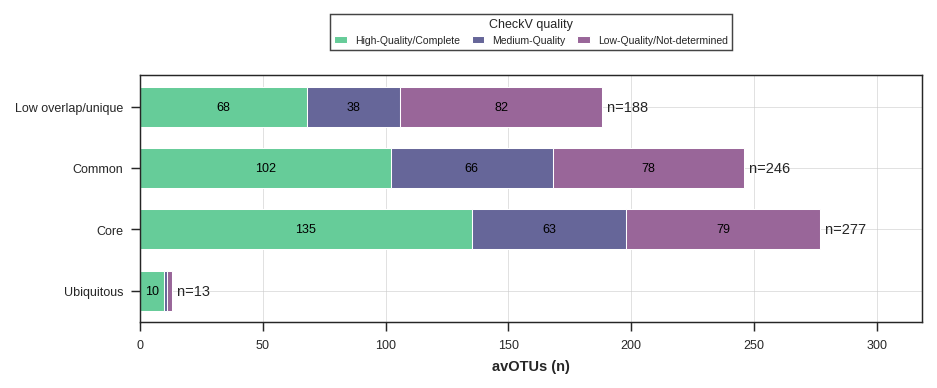

In [13]:
# Plot CheckV quality across Danish prevalence classes
# Plot CheckV quality across prevalence classes
prevalence_quality_figure_path = (
    OUTPUT_DIR / "15_Danish_prevalence_quality_composition.svg"
)

quality_composition = (
    prevalence_by_votu.loc[
        prevalence_by_votu["prevalence_group"].isin(PLOT_PREVALENCE_GROUPS)
    ]
    .groupby(["prevalence_group", "quality_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=PLOT_PREVALENCE_GROUPS,
        columns=QUALITY_CLASS_ORDER,
        fill_value=0,
    )
)

with sns.axes_style("ticks", {"axes.grid": True}), plt.rc_context(
    {
        "axes.linewidth": 0.7,
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,
        "grid.linewidth": 0.35,
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans"],
        "font.size": 5,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 5,
        "axes.labelweight": "bold",
        "svg.fonttype": "none",
    }
):
    fig, axis = plt.subplots(figsize=(6.2, 2.65))
    left = np.zeros(len(quality_composition))

    for quality_group in QUALITY_CLASS_ORDER:
        values = quality_composition[quality_group].to_numpy()
        bars = axis.barh(
            quality_composition.index,
            values,
            left=left,
            color=palette_quality[quality_group],
            edgecolor="white",
            linewidth=0.5,
            height=0.65,
            label=quality_group,
        )
        for bar, value, start in zip(bars, values, left):
            if value >= 4:
                axis.text(
                    start + value / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{int(value)}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color="black",
                )
        left += values

    for y_position, total in enumerate(quality_composition.sum(axis=1)):
        axis.text(
            total + max(1.5, quality_composition.to_numpy().max() * 0.015),
            y_position,
            f"n={int(total)}",
            va="center",
            fontsize=7,
        )

    axis.set_xlabel("avOTUs (n)")
    axis.set_ylabel("")
    axis.spines[["top", "right"]].set_visible(True)
    axis.legend(
        title="CheckV quality",
        frameon=True,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.27),
        ncol=len(QUALITY_CLASS_ORDER),
        columnspacing=1.1,
        handlelength=1.2,
    )
    axis.set_xlim(0, quality_composition.sum(axis=1).max() * 1.15)
    fig.tight_layout()
    fig.savefig(
        prevalence_quality_figure_path,
        format="svg",
        bbox_inches="tight",
    )

plt.show()
plt.close(fig)


## Lifestyle Analysis

Repeat lifestyle comparisons across the nested CheckV quality sets.

In [14]:
# Summarize lifestyle results across quality sets
def summarize_percent_values(values):
    values = pd.Series(values).dropna()
    return {
        "mean (%)": values.mean(),
        "median (%)": values.median(),
        "standard deviation (%)": values.std(ddof=1),
    }


def effect_direction(left_mean, right_mean, left_label="Temperate", right_label="Virulent"):
    if pd.isna(left_mean) or pd.isna(right_mean):
        return "not tested"
    if np.isclose(left_mean, right_mean):
        return "tie"
    if left_mean > right_mean:
        return f"{left_label} > {right_label}"
    return f"{right_label} > {left_label}"


def add_detailed_stats_row(
    rows,
    quality_set,
    metric,
    test,
    temperate_values,
    virulent_values,
    statistic,
    p_value,
    paired,
):
    temperate_values = pd.Series(temperate_values).dropna()
    virulent_values = pd.Series(virulent_values).dropna()
    temperate_stats = summarize_percent_values(temperate_values)
    virulent_stats = summarize_percent_values(virulent_values)
    rows.append(
        {
            "quality_set": quality_set,
            "metric": metric,
            "test": test,
            "paired": paired,
            "temperate_observations": len(temperate_values),
            "virulent_observations": len(virulent_values),
            "Temperate mean (%)": temperate_stats["mean (%)"],
            "Temperate median (%)": temperate_stats["median (%)"],
            "Temperate standard deviation (%)": temperate_stats[
                "standard deviation (%)"
            ],
            "Virulent mean (%)": virulent_stats["mean (%)"],
            "Virulent median (%)": virulent_stats["median (%)"],
            "Virulent standard deviation (%)": virulent_stats[
                "standard deviation (%)"
            ],
            "test statistic": statistic,
            "p-value": p_value,
            "direction by mean": effect_direction(
                temperate_stats["mean (%)"],
                virulent_stats["mean (%)"],
            ),
        }
    )


lifestyle_summary_rows = []
lifestyle_detailed_stats_rows = []

for quality_set in QUALITY_SET_ORDER:
    subset = quality_sets[quality_set]
    temperate_mask = subset["resolved_lifestyle"].eq("Temperate")
    virulent_mask = subset["resolved_lifestyle"].eq("Virulent")

    relative_rows = []
    detected_rows = []
    for sample in SAMPLES:
        total_rpkm = subset[sample].sum()
        detected = subset[sample].gt(0)
        total_detected = int(detected.sum())

        relative_rows.append(
            {
                "Temperate": (
                    100 * subset.loc[temperate_mask, sample].sum() / total_rpkm
                    if total_rpkm > 0
                    else np.nan
                ),
                "Virulent": (
                    100 * subset.loc[virulent_mask, sample].sum() / total_rpkm
                    if total_rpkm > 0
                    else np.nan
                ),
            }
        )
        detected_rows.append(
            {
                "Temperate": (
                    100 * (temperate_mask & detected).sum() / total_detected
                    if total_detected > 0
                    else np.nan
                ),
                "Virulent": (
                    100 * (virulent_mask & detected).sum() / total_detected
                    if total_detected > 0
                    else np.nan
                ),
            }
        )

    relative_abundance = pd.DataFrame(relative_rows).dropna()
    detected_proportion = pd.DataFrame(detected_rows).dropna()
    try:
        relative_result = wilcoxon(
            relative_abundance["Temperate"],
            relative_abundance["Virulent"],
            alternative="two-sided",
        )
        relative_statistic = relative_result.statistic
        relative_p_value = relative_result.pvalue
    except ValueError:
        relative_statistic = np.nan
        relative_p_value = np.nan
    try:
        detected_result = wilcoxon(
            detected_proportion["Temperate"],
            detected_proportion["Virulent"],
            alternative="two-sided",
        )
        detected_statistic = detected_result.statistic
        detected_p_value = detected_result.pvalue
    except ValueError:
        detected_statistic = np.nan
        detected_p_value = np.nan

    prevalence = 100 * subset[SAMPLES_DK].gt(0).sum(axis=1) / len(SAMPLES_DK)
    temperate_prevalence = prevalence.loc[temperate_mask]
    virulent_prevalence = prevalence.loc[virulent_mask]
    try:
        prevalence_result = mannwhitneyu(
            temperate_prevalence,
            virulent_prevalence,
            alternative="two-sided",
        )
        prevalence_statistic = prevalence_result.statistic
        prevalence_p_value = prevalence_result.pvalue
    except ValueError:
        prevalence_statistic = np.nan
        prevalence_p_value = np.nan

    add_detailed_stats_row(
        lifestyle_detailed_stats_rows,
        quality_set,
        "Per-sample lifestyle relative abundance",
        "paired two-sided Wilcoxon signed-rank",
        relative_abundance["Temperate"],
        relative_abundance["Virulent"],
        relative_statistic,
        relative_p_value,
        paired=True,
    )
    add_detailed_stats_row(
        lifestyle_detailed_stats_rows,
        quality_set,
        "Per-sample detected-vOTU representation",
        "paired two-sided Wilcoxon signed-rank",
        detected_proportion["Temperate"],
        detected_proportion["Virulent"],
        detected_statistic,
        detected_p_value,
        paired=True,
    )
    add_detailed_stats_row(
        lifestyle_detailed_stats_rows,
        quality_set,
        "Danish vOTU prevalence",
        "two-sided Mann-Whitney U",
        temperate_prevalence,
        virulent_prevalence,
        prevalence_statistic,
        prevalence_p_value,
        paired=False,
    )

    quality_row = quality_set_summary.loc[
        quality_set_summary["quality_set"].eq(quality_set)
    ].iloc[0]
    lifestyle_summary_rows.append(
        {
            "quality_set": quality_set,
            "vOTUs": int(quality_row["vOTUs"]),
            "RPKM retained (%)": quality_row["RPKM retained (%)"],
            "Temperate": int(temperate_mask.sum()),
            "Temperate (%)": quality_row["Temperate (%)"],
            "Virulent": int(virulent_mask.sum()),
            "Virulent (%)": quality_row["Virulent (%)"],
            "No lifestyle call": int(quality_row["No lifestyle call"]),
            "No lifestyle call (%)": quality_row["No lifestyle call (%)"],
            "Temperate mean relative abundance (%)": relative_abundance[
                "Temperate"
            ].mean(),
            "Virulent mean relative abundance (%)": relative_abundance[
                "Virulent"
            ].mean(),
            "Relative abundance statistic (Wilcoxon)": relative_statistic,
            "Relative abundance P (Wilcoxon)": relative_p_value,
            "Temperate mean prevalence (%)": temperate_prevalence.mean(),
            "Virulent mean prevalence (%)": virulent_prevalence.mean(),
            "Prevalence statistic (Mann-Whitney U)": prevalence_statistic,
            "Prevalence P (Mann-Whitney U)": prevalence_p_value,
            "Temperate mean detected vOTUs (%)": detected_proportion[
                "Temperate"
            ].mean(),
            "Virulent mean detected vOTUs (%)": detected_proportion[
                "Virulent"
            ].mean(),
            "Detected vOTUs statistic (Wilcoxon)": detected_statistic,
            "Detected vOTUs P (Wilcoxon)": detected_p_value,
        }
    )

lifestyle_quality_summary = pd.DataFrame(lifestyle_summary_rows)
lifestyle_quality_detailed_stats = pd.DataFrame(lifestyle_detailed_stats_rows)
direction_consistency_rows = []
for metric, metric_df in lifestyle_quality_detailed_stats.groupby("metric", sort=False):
    directions = metric_df["direction by mean"].dropna().unique().tolist()
    tested_directions = [direction for direction in directions if direction != "not tested"]
    direction_consistency_rows.append(
        {
            "metric": metric,
            "consistent_across_quality_sets": len(set(tested_directions)) == 1,
            "direction across quality sets": (
                tested_directions[0]
                if len(set(tested_directions)) == 1 and tested_directions
                else "; ".join(tested_directions)
            ),
            "quality_sets_checked": len(metric_df),
        }
    )
lifestyle_direction_consistency = pd.DataFrame(direction_consistency_rows)

lifestyle_quality_summary.to_csv(
    OUTPUT_DIR / "15_lifestyle_quality_summary.csv",
    index=False,
)
lifestyle_quality_detailed_stats.to_csv(
    OUTPUT_DIR / "15_lifestyle_quality_detailed_stats.csv",
    index=False,
)
lifestyle_quality_detailed_stats.to_csv(
    SUP_FIGS_TABLES_DIR / "STable8_vOTU_quality_lifestyle_robustness.csv",
    index=False,
)
lifestyle_direction_consistency.to_csv(
    OUTPUT_DIR / "15_lifestyle_direction_consistency.csv",
    index=False,
)

lifestyle_quality_display = lifestyle_quality_summary.copy()
for column in lifestyle_quality_display.columns:
    if (
        "mean" in column
        or "(%)" in column
        or column == "RPKM retained (%)"
        or " statistic " in column
    ):
        lifestyle_quality_display[column] = lifestyle_quality_display[column].round(3)
    if " P (" in column:
        lifestyle_quality_display[column] = (
            lifestyle_quality_display[column].map(format_p_value)
        )
lifestyle_quality_display

lifestyle_detailed_display = lifestyle_quality_detailed_stats.copy()
for column in lifestyle_detailed_display.columns:
    if "(%)" in column or column == "test statistic":
        lifestyle_detailed_display[column] = lifestyle_detailed_display[column].round(3)
lifestyle_detailed_display["p-value"] = lifestyle_detailed_display["p-value"].map(
    format_p_value
)
with pd.option_context("display.max_columns", None):
    lifestyle_detailed_display

lifestyle_direction_consistency


,metric,consistent_across_quality_sets,direction across quality sets,quality_sets_checked
0,Per-sample lifestyle relative abundance,True,Temperate > Virulent,3
1,Per-sample detected-vOTU representation,True,Temperate > Virulent,3
2,Danish vOTU prevalence,True,Temperate > Virulent,3


## Community Concordance

Repeat Figure 4b distance comparisons across quality sets.

In [15]:
# Recalculate and compare community distance matrices
def read_distance_matrix(path):
    matrix = pd.read_csv(path, index_col=0)
    matrix.index = matrix.index.astype(str)
    matrix.columns = matrix.columns.astype(str)

    if set(matrix.index) != set(matrix.columns):
        raise ValueError(f"Distance matrix index and columns differ: {path}")
    matrix = matrix.loc[matrix.index, matrix.index]

    if not np.allclose(matrix.to_numpy(), matrix.to_numpy().T, atol=1e-10):
        raise ValueError(f"Distance matrix is not symmetric: {path}")
    if not np.allclose(np.diag(matrix.to_numpy()), 0, atol=1e-10):
        raise ValueError(f"Distance matrix diagonal is not zero: {path}")
    return matrix


def viral_distance_matrix(subset, virome_samples, sample_labels, metric):
    counts = (
        subset.set_index("vOTU")
        .loc[:, virome_samples]
        .T
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
    )

    if metric == "Jaccard":
        distances = squareform(
            pdist(counts.gt(0).to_numpy(dtype=bool), metric="jaccard")
        )
    elif metric == "Hellinger":
        relative = counts.div(
            counts.sum(axis=1).replace(0, np.nan),
            axis=0,
        ).fillna(0.0)
        distances = (
            squareform(pdist(np.sqrt(relative).to_numpy(), metric="euclidean"))
            / np.sqrt(2)
        )
    else:
        raise ValueError(f"Unsupported community metric: {metric}")

    return pd.DataFrame(
        distances,
        index=sample_labels,
        columns=sample_labels,
    )


def mantel_spearman(left, right, rng):
    left = np.asarray(left, dtype=float)
    right = np.asarray(right, dtype=float)
    if left.shape != right.shape or left.shape[0] != left.shape[1]:
        raise ValueError("Mantel matrices must be square and have the same shape.")

    n_samples = left.shape[0]
    upper = np.triu_indices(n_samples, k=1)
    left_ranks = rankdata(left[upper])
    right_ranks = rankdata(right[upper])

    left_centered = left_ranks - left_ranks.mean()
    left_norm = np.linalg.norm(left_centered)
    right_centered = right_ranks - right_ranks.mean()
    right_norm = np.linalg.norm(right_centered)
    if left_norm == 0 or right_norm == 0:
        return np.nan, np.nan

    observed_rho = np.dot(left_centered, right_centered) / (left_norm * right_norm)

    rank_matrix = np.zeros_like(right, dtype=float)
    rank_matrix[upper] = right_ranks
    rank_matrix[(upper[1], upper[0])] = right_ranks

    n_as_extreme = 0
    for _ in range(N_MANTEL_PERMUTATIONS):
        permutation = rng.permutation(n_samples)
        permuted_ranks = rank_matrix[np.ix_(permutation, permutation)][upper]
        permuted_centered = permuted_ranks - permuted_ranks.mean()
        permuted_norm = np.linalg.norm(permuted_centered)
        if permuted_norm == 0:
            continue
        permuted_rho = (
            np.dot(left_centered, permuted_centered)
            / (left_norm * permuted_norm)
        )
        if abs(permuted_rho) >= abs(observed_rho):
            n_as_extreme += 1

    p_value = (n_as_extreme + 1) / (N_MANTEL_PERMUTATIONS + 1)
    return observed_rho, p_value


bacterial_jaccard = read_distance_matrix(BACTERIAL_JACCARD_PATH)
bacterial_hellinger = read_distance_matrix(BACTERIAL_HELLINGER_PATH)
viral_jaccard_reference = read_distance_matrix(VIRAL_JACCARD_PATH)
viral_hellinger_reference = read_distance_matrix(VIRAL_HELLINGER_PATH)

matched_sample_labels = bacterial_jaccard.index.tolist()
if set(bacterial_hellinger.index) != set(matched_sample_labels):
    raise ValueError("The bacterial Jaccard and Hellinger matrices use different samples.")
if set(viral_jaccard_reference.index) != set(matched_sample_labels):
    raise ValueError("The bacterial and viral Jaccard matrices use different samples.")
if set(viral_hellinger_reference.index) != set(matched_sample_labels):
    raise ValueError("The bacterial and viral Hellinger matrices use different samples.")

bacterial_hellinger = bacterial_hellinger.loc[
    matched_sample_labels,
    matched_sample_labels,
]
viral_jaccard_reference = viral_jaccard_reference.loc[
    matched_sample_labels,
    matched_sample_labels,
]
viral_hellinger_reference = viral_hellinger_reference.loc[
    matched_sample_labels,
    matched_sample_labels,
]

matched_virome_samples = [f"v{sample}" for sample in matched_sample_labels]
missing_matched_virome_samples = sorted(
    set(matched_virome_samples).difference(selected_votus.columns)
)
if missing_matched_virome_samples:
    raise ValueError(
        "The 1.5x RPKM table is missing paired virome samples: "
        f"{missing_matched_virome_samples}"
    )

viral_distance_matrices = {}
for quality_set in QUALITY_SET_ORDER:
    subset = quality_sets[quality_set]
    viral_distance_matrices[quality_set] = {
        "Jaccard": viral_distance_matrix(
            subset,
            matched_virome_samples,
            matched_sample_labels,
            "Jaccard",
        ),
        "Hellinger": viral_distance_matrix(
            subset,
            matched_virome_samples,
            matched_sample_labels,
            "Hellinger",
        ),
    }

reference_matrices = {
    "Jaccard": viral_jaccard_reference,
    "Hellinger": viral_hellinger_reference,
}
reconstruction_rows = []
for metric, _, _ in COMMUNITY_METRICS:
    maximum_absolute_difference = np.abs(
        viral_distance_matrices["All vOTUs"][metric].to_numpy()
        - reference_matrices[metric].to_numpy()
    ).max()
    reconstruction_rows.append(
        {
            "metric": metric,
            "maximum_absolute_difference": maximum_absolute_difference,
        }
    )
    if maximum_absolute_difference > 1e-8:
        raise ValueError(
            f"The all-vOTU {metric} matrix does not reproduce the saved "
            f"manuscript matrix (maximum difference "
            f"{maximum_absolute_difference:.3g})."
        )

community_reconstruction_check = pd.DataFrame(reconstruction_rows)
community_reconstruction_check.to_csv(
    OUTPUT_DIR / "15_all_vOTU_distance_reconstruction_check.csv",
    index=False,
)
community_reconstruction_check

bacterial_distance_matrices = {
    "Jaccard": bacterial_jaccard,
    "Hellinger": bacterial_hellinger,
}
rng = np.random.default_rng(RANDOM_SEED)
community_summary_rows = []
viral_metric_summary_rows = []

for quality_set in QUALITY_SET_ORDER:
    viral_metric_mantel_rho, viral_metric_mantel_p_value = mantel_spearman(
        viral_distance_matrices[quality_set]["Jaccard"].to_numpy(),
        viral_distance_matrices[quality_set]["Hellinger"].to_numpy(),
        rng,
    )
    viral_metric_summary_rows.append(
        {
            "quality_set": quality_set,
            "matched_samples": len(matched_sample_labels),
            "viral_jaccard_hellinger_mantel_rho": viral_metric_mantel_rho,
            "viral_jaccard_hellinger_mantel_p_value": (
                viral_metric_mantel_p_value
            ),
        }
    )

    for metric, _, _ in COMMUNITY_METRICS:
        viral_matrix = viral_distance_matrices[quality_set][metric]
        bacterial_matrix = bacterial_distance_matrices[metric]

        mantel_rho, mantel_p_value = mantel_spearman(
            bacterial_matrix.to_numpy(),
            viral_matrix.to_numpy(),
            rng,
        )
        community_summary_rows.append(
            {
                "quality_set": quality_set,
                "metric": metric,
                "matched_samples": len(matched_sample_labels),
                "bacterial_viral_mantel_rho": mantel_rho,
                "bacterial_viral_mantel_p_value": mantel_p_value,
            }
        )

community_concordance_summary = pd.DataFrame(community_summary_rows)
viral_metric_concordance_summary = pd.DataFrame(viral_metric_summary_rows)
community_concordance_summary["quality_set"] = pd.Categorical(
    community_concordance_summary["quality_set"],
    categories=QUALITY_SET_ORDER,
    ordered=True,
)
viral_metric_concordance_summary["quality_set"] = pd.Categorical(
    viral_metric_concordance_summary["quality_set"],
    categories=QUALITY_SET_ORDER,
    ordered=True,
)
community_concordance_summary.to_csv(
    OUTPUT_DIR / "15_bacterial_viral_community_concordance.csv",
    index=False,
)
viral_metric_concordance_summary.to_csv(
    OUTPUT_DIR / "15_viral_jaccard_hellinger_concordance.csv",
    index=False,
)

community_display = community_concordance_summary.copy()
community_display["bacterial_viral_mantel_rho"] = (
    community_display["bacterial_viral_mantel_rho"].round(3)
)
community_display["bacterial_viral_mantel_p_value"] = (
    community_display["bacterial_viral_mantel_p_value"].map(format_p_value)
)
community_display

viral_metric_display = viral_metric_concordance_summary.copy()
viral_metric_display["viral_jaccard_hellinger_mantel_rho"] = (
    viral_metric_display["viral_jaccard_hellinger_mantel_rho"].round(3)
)
viral_metric_display["viral_jaccard_hellinger_mantel_p_value"] = (
    viral_metric_display["viral_jaccard_hellinger_mantel_p_value"].map(
        format_p_value
    )
)
viral_metric_display


,quality_set,matched_samples,viral_jaccard_hellinger_mantel_rho,viral_jaccard_hellinger_mantel_p_value
0,All vOTUs,35,0.409,<0.001
1,Medium-quality or better,35,0.327,0.004
2,High-quality or Complete,35,0.316,0.009


### Bacterial–Viral and Viral-Metric Concordance

Use 9,999-permutation Spearman Mantel tests on the matched samples.

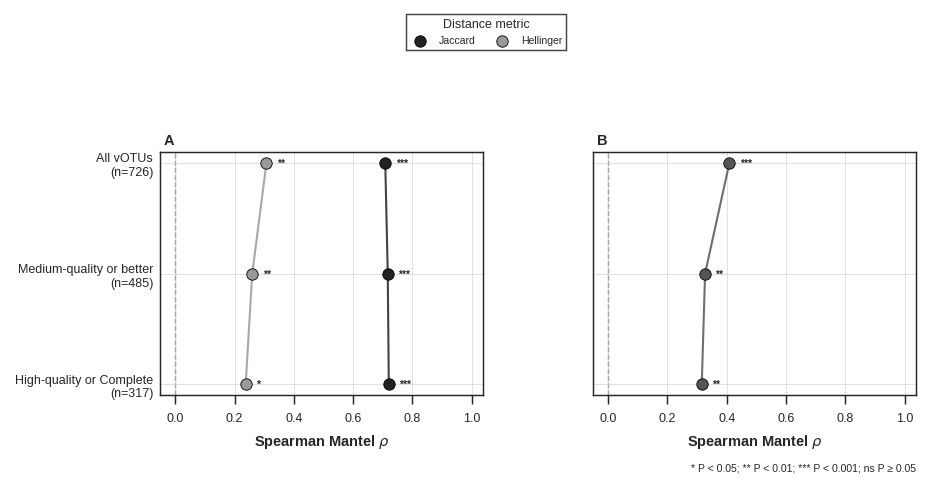

In [16]:
# Plot community concordance across quality sets
community_figure_path = OUTPUT_DIR / "15_community_concordance_by_quality.svg"

quality_plot_labels = {
    row["quality_set"]: f'{row["quality_set"]}\n(n={int(row["vOTUs"])})'
    for _, row in quality_set_summary.iterrows()
}
quality_y_positions = np.arange(len(QUALITY_SET_ORDER))[::-1]

with sns.axes_style("ticks", {"axes.grid": True}), plt.rc_context(
    {
        "axes.linewidth": 0.7,
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,
        "grid.linewidth": 0.35,
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans"],
        "font.size": 5,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 5,
        "axes.labelweight": "bold",
        "axes.titleweight": "bold",
        "svg.fonttype": "none",
    }
):
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(7.0, 2.8),
        sharey=True,
    )

    legend_handles = []
    for metric, metric_label, metric_color in COMMUNITY_METRICS:
        metric_rows = (
            community_concordance_summary.loc[
                community_concordance_summary["metric"].eq(metric)
            ]
            .set_index("quality_set")
            .reindex(QUALITY_SET_ORDER)
        )
        values = metric_rows["bacterial_viral_mantel_rho"].to_numpy()
        axes[0].plot(
            values,
            quality_y_positions,
            color=metric_color,
            linewidth=1.0,
            alpha=0.85,
            zorder=2,
        )
        legend_handles.append(
            axes[0].scatter(
                values,
                quality_y_positions,
                color=metric_color,
                edgecolor="black",
                linewidth=0.4,
                s=30,
                zorder=3,
                label=metric_label,
            )
        )
        for value, y_position, p_value in zip(
            values,
            quality_y_positions,
            metric_rows["bacterial_viral_mantel_p_value"].to_numpy(),
        ):
            axes[0].annotate(
                significance_label(p_value),
                (value, y_position),
                xytext=(5, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=5,
                fontweight="bold",
            )

    viral_metric_rows = (
        viral_metric_concordance_summary.set_index("quality_set")
        .reindex(QUALITY_SET_ORDER)
    )
    viral_metric_values = viral_metric_rows[
        "viral_jaccard_hellinger_mantel_rho"
    ].to_numpy()
    axes[1].plot(
        viral_metric_values,
        quality_y_positions,
        color="#555555",
        linewidth=1.0,
        alpha=0.85,
        zorder=2,
    )
    axes[1].scatter(
        viral_metric_values,
        quality_y_positions,
        color="#555555",
        edgecolor="black",
        linewidth=0.4,
        s=30,
        zorder=3,
    )
    for value, y_position, p_value in zip(
        viral_metric_values,
        quality_y_positions,
        viral_metric_rows[
            "viral_jaccard_hellinger_mantel_p_value"
        ].to_numpy(),
    ):
        axes[1].annotate(
            significance_label(p_value),
            (value, y_position),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=5,
            fontweight="bold",
        )
    for axis in axes:
        axis.axvline(0, color="#777777", linestyle="--", linewidth=0.65, zorder=0)
        axis.set_xlabel(r"Spearman Mantel $\rho$")
        axis.set_xlim(-0.05, 1.04)
        axis.spines[["top", "right"]].set_visible(True)
        axis.tick_params(axis="y", length=0)

    for axis, panel_label in zip(axes, "AB"):
        axis.text(
            0.01, 1.02, panel_label, transform=axis.transAxes,
            fontsize=7, fontweight="bold", ha="left", va="bottom", zorder=10,
        )

    axes[0].set_yticks(quality_y_positions)
    axes[0].set_yticklabels(
        [quality_plot_labels[quality_set] for quality_set in QUALITY_SET_ORDER]
    )
    axes[1].tick_params(axis="y", labelleft=False)

    fig.legend(
        legend_handles,
        [label for _, label, _ in COMMUNITY_METRICS],
        title="Distance metric",
        frameon=True,
        ncol=2,
        loc="upper center",
        bbox_to_anchor=(0.58, 1.12),
        columnspacing=1.5,
    )
    fig.text(
        0.99,
        0.02,
        "* P < 0.05; ** P < 0.01; *** P < 0.001; ns P ≥ 0.05",
        ha="right",
        fontsize=5,
    )
    fig.subplots_adjust(left=0.27, right=0.99, bottom=0.2, top=0.78, wspace=0.34)
    fig.savefig(community_figure_path, format="svg", bbox_inches="tight")

plt.show()
plt.close(fig)


## Summary Statistics

In [17]:
# Export the complete quality-robustness summary
# Export complete quality-robustness summary
full_summary_rows = []

for quality_set in QUALITY_SET_ORDER:
    subset = quality_sets[quality_set]
    subset_votu_ids = set(subset["vOTU"])
    prevalence_counts = (
        prevalence_by_votu.loc[
            prevalence_by_votu["vOTU"].isin(subset_votu_ids),
            "prevalence_group",
        ]
        .value_counts()
        .reindex(PREVALENCE_GROUP_ORDER, fill_value=0)
    )

    quality_row = quality_set_summary.loc[
        quality_set_summary["quality_set"].eq(quality_set)
    ].iloc[0]
    lifestyle_row = lifestyle_quality_summary.loc[
        lifestyle_quality_summary["quality_set"].eq(quality_set)
    ].iloc[0]

    summary_row = {
        "quality_set": quality_set,
        "CheckV calls included": quality_row["CheckV calls included"],
        "vOTUs": int(quality_row["vOTUs"]),
        "Temperate": int(quality_row["Temperate"]),
        "Temperate (%)": quality_row["Temperate (%)"],
        "Virulent": int(quality_row["Virulent"]),
        "Virulent (%)": quality_row["Virulent (%)"],
        "No lifestyle call": int(quality_row["No lifestyle call"]),
        "No lifestyle call (%)": quality_row["No lifestyle call (%)"],
        "RPKM retained (%)": quality_row["RPKM retained (%)"],
        "Danish samples (n)": len(SAMPLES_DK),
        "Danish detected vOTUs": int(
            len(subset) - prevalence_counts["Not detected in Danish samples"]
        ),
        "Danish not detected vOTUs": int(
            prevalence_counts["Not detected in Danish samples"]
        ),
        "Danish low overlap/unique vOTUs": int(
            prevalence_counts["Low overlap/unique"]
        ),
        "Danish common vOTUs": int(prevalence_counts["Common"]),
        "Danish core vOTUs": int(prevalence_counts["Core"]),
        "Danish ubiquitous vOTUs": int(prevalence_counts["Ubiquitous"]),
        "Relative abundance samples (n)": len(SAMPLES),
        "Temperate mean relative abundance (%)": lifestyle_row[
            "Temperate mean relative abundance (%)"
        ],
        "Virulent mean relative abundance (%)": lifestyle_row[
            "Virulent mean relative abundance (%)"
        ],
        "Relative abundance statistic (Wilcoxon)": lifestyle_row[
            "Relative abundance statistic (Wilcoxon)"
        ],
        "Relative abundance P (Wilcoxon)": lifestyle_row[
            "Relative abundance P (Wilcoxon)"
        ],
        "Prevalence samples (n)": len(SAMPLES_DK),
        "Temperate mean prevalence (%)": lifestyle_row[
            "Temperate mean prevalence (%)"
        ],
        "Virulent mean prevalence (%)": lifestyle_row[
            "Virulent mean prevalence (%)"
        ],
        "Prevalence statistic (Mann-Whitney U)": lifestyle_row[
            "Prevalence statistic (Mann-Whitney U)"
        ],
        "Prevalence P (Mann-Whitney U)": lifestyle_row[
            "Prevalence P (Mann-Whitney U)"
        ],
        "Detected-vOTU samples (n)": len(SAMPLES),
        "Temperate mean detected vOTUs (%)": lifestyle_row[
            "Temperate mean detected vOTUs (%)"
        ],
        "Virulent mean detected vOTUs (%)": lifestyle_row[
            "Virulent mean detected vOTUs (%)"
        ],
        "Detected vOTUs statistic (Wilcoxon)": lifestyle_row[
            "Detected vOTUs statistic (Wilcoxon)"
        ],
        "Detected vOTUs P (Wilcoxon)": lifestyle_row[
            "Detected vOTUs P (Wilcoxon)"
        ],
    }

    for metric, _, _ in COMMUNITY_METRICS:
        metric_row = community_concordance_summary.loc[
            community_concordance_summary["quality_set"].eq(quality_set)
            & community_concordance_summary["metric"].eq(metric)
        ].iloc[0]
        summary_row[f"{metric} matched samples (n)"] = int(
            metric_row["matched_samples"]
        )
        summary_row[f"{metric} Mantel rho"] = metric_row[
            "bacterial_viral_mantel_rho"
        ]
        summary_row[f"{metric} Mantel P"] = metric_row[
            "bacterial_viral_mantel_p_value"
        ]

    viral_metric_row = viral_metric_concordance_summary.loc[
        viral_metric_concordance_summary["quality_set"].eq(quality_set)
    ].iloc[0]
    summary_row["Viral Jaccard-Hellinger matched samples (n)"] = int(
        viral_metric_row["matched_samples"]
    )
    summary_row["Viral Jaccard-Hellinger Mantel rho"] = (
        viral_metric_row["viral_jaccard_hellinger_mantel_rho"]
    )
    summary_row["Viral Jaccard-Hellinger Mantel P"] = (
        viral_metric_row["viral_jaccard_hellinger_mantel_p_value"]
    )

    full_summary_rows.append(summary_row)

full_quality_robustness_summary = pd.DataFrame(full_summary_rows)
full_quality_robustness_summary.to_csv(
    OUTPUT_DIR / "15_full_quality_robustness_summary.csv",
    index=False,
)

full_summary_display = full_quality_robustness_summary.copy()
round_columns = [
    "Temperate (%)",
    "Virulent (%)",
    "No lifestyle call (%)",
    "RPKM retained (%)",
    "Temperate mean relative abundance (%)",
    "Virulent mean relative abundance (%)",
    "Relative abundance statistic (Wilcoxon)",
    "Temperate mean prevalence (%)",
    "Virulent mean prevalence (%)",
    "Prevalence statistic (Mann-Whitney U)",
    "Temperate mean detected vOTUs (%)",
    "Virulent mean detected vOTUs (%)",
    "Detected vOTUs statistic (Wilcoxon)",
    "Jaccard Mantel rho",
    "Hellinger Mantel rho",
    "Viral Jaccard-Hellinger Mantel rho",
]
full_summary_display[round_columns] = (
    full_summary_display[round_columns].round(3)
)
for column in [
    "Relative abundance P (Wilcoxon)",
    "Prevalence P (Mann-Whitney U)",
    "Detected vOTUs P (Wilcoxon)",
    "Jaccard Mantel P",
    "Hellinger Mantel P",
    "Viral Jaccard-Hellinger Mantel P",
]:
    full_summary_display[column] = full_summary_display[column].map(
        format_p_value
    )

with pd.option_context("display.max_columns", None):
    full_summary_display


## Supplementary Figure: avOTU Quality Robustness

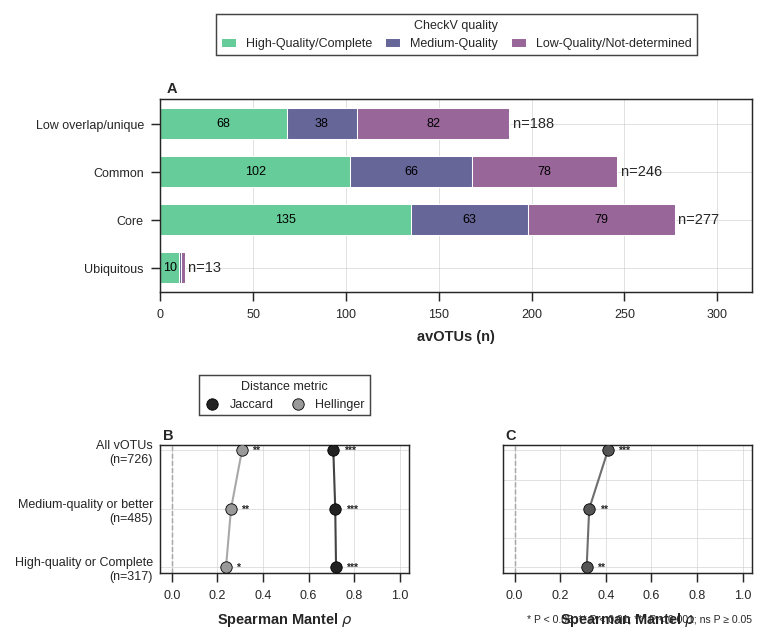

In [18]:
# Plot the combined quality-robustness figure
# Plot combined quality-robustness figure
multiplot_path = OUTPUT_DIR / "15_quality_robustness_multiplot.svg"

with sns.axes_style("ticks", {"axes.grid": True}), plt.rc_context(
    {
        "axes.linewidth": 0.7,
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,
        "grid.linewidth": 0.35,
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "axes.labelweight": "bold",
        "axes.titleweight": "bold",
        "svg.fonttype": "none",
    }
):
    fig = plt.figure(figsize=(5.4, 4.1))
    grid = fig.add_gridspec(
        nrows=2,
        ncols=2,
        height_ratios=[1.0, 2 / 3],
        hspace=0.95,
        wspace=0.38,
    )
    quality_axis = fig.add_subplot(grid[0, :])
    community_axes = [
        fig.add_subplot(grid[1, 0]),
        fig.add_subplot(grid[1, 1]),
    ]

    left = np.zeros(len(quality_composition))
    quality_handles = []
    for quality_group in QUALITY_CLASS_ORDER:
        values = quality_composition[quality_group].to_numpy()
        bars = quality_axis.barh(
            quality_composition.index,
            values,
            left=left,
            color=palette_quality[quality_group],
            edgecolor="white",
            linewidth=0.5,
            height=0.65,
            label=quality_group,
        )
        quality_handles.append(bars[0])
        for bar, value, start in zip(bars, values, left):
            if value >= 4:
                quality_axis.text(
                    start + value / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{int(value)}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color="black",
                )
        left += values

    for y_position, total in enumerate(quality_composition.sum(axis=1)):
        quality_axis.text(
            total + max(1.5, quality_composition.to_numpy().max() * 0.015),
            y_position,
            f"n={int(total)}",
            va="center",
            fontsize=7,
        )

    quality_axis.set_xlabel("avOTUs (n)")
    quality_axis.set_ylabel("")
    quality_axis.set_xlim(0, quality_composition.sum(axis=1).max() * 1.15)
    quality_axis.spines[["top", "right"]].set_visible(True)
    quality_axis.legend(
        quality_handles,
        QUALITY_CLASS_ORDER,
        title="CheckV quality",
        frameon=True,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.20),
        ncol=len(QUALITY_CLASS_ORDER),
        columnspacing=1.05,
        handlelength=1.2,
    )

    metric_handles = []

    for metric, metric_label, metric_color in COMMUNITY_METRICS:
        metric_rows = (
            community_concordance_summary.loc[
                community_concordance_summary["metric"].eq(metric)
            ]
            .set_index("quality_set")
            .reindex(QUALITY_SET_ORDER)
        )
        values = metric_rows["bacterial_viral_mantel_rho"].to_numpy()
        community_axes[0].plot(
            values,
            quality_y_positions,
            color=metric_color,
            linewidth=1.0,
            alpha=0.85,
            zorder=2,
        )
        metric_handles.append(
            community_axes[0].scatter(
                values,
                quality_y_positions,
                color=metric_color,
                edgecolor="black",
                linewidth=0.4,
                s=30,
                zorder=3,
                label=metric_label,
            )
        )
        for value, y_position, p_value in zip(
            values,
            quality_y_positions,
            metric_rows["bacterial_viral_mantel_p_value"].to_numpy(),
        ):
            community_axes[0].annotate(
                significance_label(p_value),
                (value, y_position),
                xytext=(5, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=5,
                fontweight="bold",
            )

    viral_metric_rows = (
        viral_metric_concordance_summary.set_index("quality_set")
        .reindex(QUALITY_SET_ORDER)
    )
    viral_metric_values = viral_metric_rows[
        "viral_jaccard_hellinger_mantel_rho"
    ].to_numpy()
    community_axes[1].plot(
        viral_metric_values,
        quality_y_positions,
        color="#555555",
        linewidth=1.0,
        alpha=0.85,
        zorder=2,
    )
    community_axes[1].scatter(
        viral_metric_values,
        quality_y_positions,
        color="#555555",
        edgecolor="black",
        linewidth=0.4,
        s=30,
        zorder=3,
    )
    for value, y_position, p_value in zip(
        viral_metric_values,
        quality_y_positions,
        viral_metric_rows[
            "viral_jaccard_hellinger_mantel_p_value"
        ].to_numpy(),
    ):
        community_axes[1].annotate(
            significance_label(p_value),
            (value, y_position),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=5,
            fontweight="bold",
        )
    for axis in community_axes:
        axis.axvline(
            0,
            color="#777777",
            linestyle="--",
            linewidth=0.65,
            zorder=0,
        )
        axis.set_xlabel(r"Spearman Mantel $\rho$")
        axis.set_xlim(-0.05, 1.04)
        axis.spines[["top", "right"]].set_visible(True)
        axis.tick_params(axis="y", length=0)

    for axis, panel_label in zip(
        [quality_axis, *community_axes], "ABC"
    ):
        axis.text(
            0.01, 1.02, panel_label, transform=axis.transAxes,
            fontsize=7, fontweight="bold", ha="left", va="bottom", zorder=10,
        )

    community_axes[0].set_yticks(quality_y_positions)
    community_axes[0].set_yticklabels(
        [quality_plot_labels[quality_set] for quality_set in QUALITY_SET_ORDER]
    )
    community_axes[1].tick_params(axis="y", labelleft=False)
    community_axes[0].legend(
        metric_handles,
        [label for _, label, _ in COMMUNITY_METRICS],
        title="Distance metric",
        frameon=True,
        ncol=2,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.18),
        columnspacing=1.35,
        handlelength=1.2,
    )

    fig.text(
        0.98,
        0.02,
        "* P < 0.05; ** P < 0.01; *** P < 0.001; ns P ≥ 0.05",
        ha="right",
        fontsize=5,
    )

    fig.subplots_adjust(
        left=0.25,
        right=0.98,
        bottom=0.10,
        top=0.87,
        hspace=0.95,
        wspace=0.38,
    )
    fig.savefig(multiplot_path, format="svg", bbox_inches="tight")
    fig.savefig(
        SUP_FIGS_TABLES_DIR / "SFigure5_vOTU_quality_robustness.svg",
        format="svg",
        bbox_inches="tight",
    )

plt.show()
plt.close(fig)